# Anomaly Detection — catch the shock, explain the cause

Profitly's alerts combine three production techniques (imported from
`app.services.anomaly`): **Isolation Forest** for multivariate point outliers,
**PELT** changepoint detection for regime shifts, and **KL-divergence** on the
audience mix to attribute the cause. This notebook shows them finding and
explaining the planted day-60 audience shift.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
sys.path.insert(0, str((ROOT.parent / "backend").resolve()))
DATA = ROOT / "data"
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.25})
ACCENT, INK, NEG = "#b8530e", "#1a1712", "#a12a1e"

from app.services.anomaly.attribute import attribute_geo_shift  # noqa: E402
from app.services.anomaly.detect import isolation_forest_flags, pelt_changepoints  # noqa: E402
from app.services.anomaly.service import detect_anomalies  # noqa: E402

## Build the daily metrics frame
Per-day revenue, views, views-weighted CPM, and views-weighted country shares
(`geo_<CC>`) — the same shape the production detector consumes.

In [2]:
daily = pd.read_csv(DATA / "daily_analytics.csv", parse_dates=["date"])
countries = ["US", "IN", "BR", "GB", "DE"]
for cc in countries:
    daily[f"s_{cc}"] = daily.country_top.apply(
        lambda r: json.loads(r).get(cc, 0.0) if isinstance(r, str) and r else 0.0)

g = daily.groupby("date")
df = pd.DataFrame({
    "revenue": g.revenue_usd.sum(),
    "views": g.views.sum(),
    "cpm": g.apply(lambda x: np.average(x.cpm_usd.fillna(0), weights=x.views)),
})
for cc in countries:
    df[f"geo_{cc}"] = g.apply(lambda x, c=cc: np.average(x[f"s_{c}"], weights=x.views))
print(df.shape); df.head(3).round(3)

(90, 8)


C:\Users\aaqui\AppData\Local\Temp\claude\ipykernel_35544\213995984.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "cpm": g.apply(lambda x: np.average(x.cpm_usd.fillna(0), weights=x.views)),
C:\Users\aaqui\AppData\Local\Temp\claude\ipykernel_35544\213995984.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[f"geo_{cc}"] = g.apply(lambda x, c=cc: np.average(x[f"s_{c}"], weights=x.views))
C:\Users\a

,revenue,views,cpm,geo_US,geo_IN,geo_BR,geo_GB,geo_DE
date,,,,,,,,
2026-02-28,5.184,4328,2.679,0.531,0.203,0.092,0.097,0.077
2026-03-01,4.368,3528,2.828,0.475,0.204,0.109,0.109,0.102
2026-03-02,5.522,4659,2.802,0.480,0.214,0.081,0.093,0.132


## 1. Changepoint on the audience mix (not on CPM)
A key design choice: run PELT on the most volatile **geography**, not on the
noisy CPM series. CPM produces spurious breaks and *misses* the real shift;
the US share has a clean step.

changepoint on geo_IN -> ['2026-04-29']
changepoint on cpm    -> ['2026-03-05', '2026-03-20', '2026-04-04']


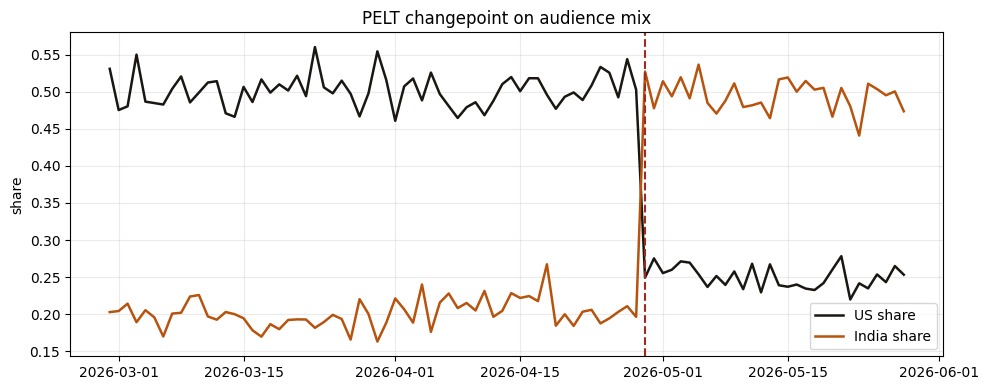

In [3]:
target = max((c for c in df.columns if c.startswith("geo_")),
             key=lambda c: df[c].max() - df[c].min())
cps_geo = pelt_changepoints(df[target])
cps_cpm = pelt_changepoints(df["cpm"])
print("changepoint on", target, "->", [df.index[i].date().isoformat() for i in cps_geo])
print("changepoint on cpm    ->", [df.index[i].date().isoformat() for i in cps_cpm])

fig, ax = plt.subplots()
ax.plot(df.index, df.geo_US, color=INK, lw=1.8, label="US share")
ax.plot(df.index, df.geo_IN, color=ACCENT, lw=1.8, label="India share")
for i in cps_geo:
    ax.axvline(df.index[i], color=NEG, ls="--", lw=1.5)
ax.set(title="PELT changepoint on audience mix", ylabel="share", xlabel="")
ax.legend(); plt.tight_layout(); plt.show()

## 2. Attribute the cause with KL-divergence
Compare the audience distribution before vs after the changepoint.

In [4]:
cp = cps_geo[0]
attr = attribute_geo_shift(df, cp)
print(f"changepoint: {df.index[cp].date()}")
print(f"KL divergence: {attr['kl']:.3f}")
print("cause:", attr["cause"])

changepoint: 2026-04-29
KL divergence: 0.232
cause: Audience mix shifted: US share -25pts, IN +29pts. Lower-CPM geography now larger.


## 3. Multivariate point outliers (Isolation Forest)
Over standardized [revenue, views, CPM], flag days that are joint outliers.

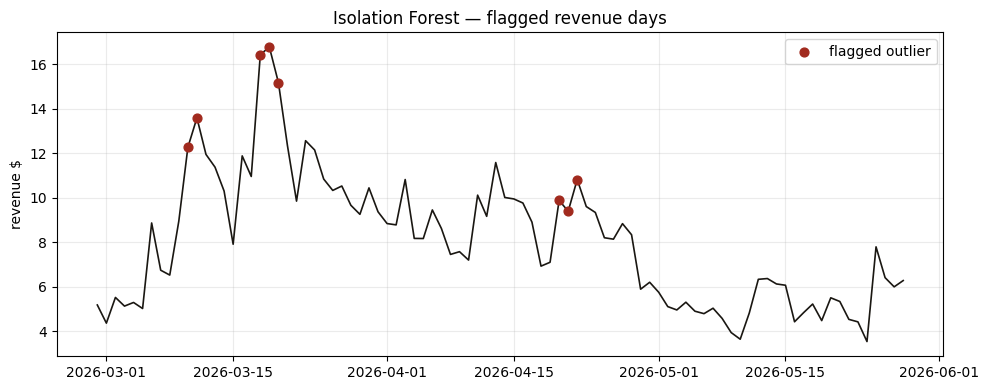

In [5]:
flags = isolation_forest_flags(df)
fig, ax = plt.subplots()
ax.plot(df.index, df.revenue, color=INK, lw=1.2)
ax.scatter(df.index[flags.values], df.revenue[flags.values],
           color=NEG, zorder=5, s=40, label="flagged outlier")
ax.set(title="Isolation Forest — flagged revenue days", ylabel="revenue $", xlabel="")
ax.legend(); plt.tight_layout(); plt.show()

## 4. The production feed
`detect_anomalies` combines all three into the ranked, explained alert list the
dashboard renders.

In [6]:
out = detect_anomalies(df)
print("detectors:", out["detectors"])
pd.DataFrame(out["items"])[["date", "severity", "metric", "delta", "cause"]]

detectors: ['isolation_forest', 'pelt_changepoint', 'kl_divergence']


,date,severity,metric,delta,cause
0,2026-04-29,high,Effective CPM,-22.9,"Audience mix shifted: US share -25pts, IN +29p..."
1,2026-04-22,high,Views,37.2,Views deviated +37% from its 14-day norm (mult...
2,2026-04-19,medium,Effective CPM,-15.7,"Audience mix shifted: US share -12pts, IN +14p..."
3,2026-03-18,high,Views,125.9,Views deviated +126% from its 14-day norm (mul...
4,2026-03-11,high,Revenue,146.1,Revenue deviated +146% from its 14-day norm (m...


## Takeaways
- PELT on the **audience distribution** lands exactly on the planted shift;
  PELT on CPM does not — choosing the right signal is the whole game.
- **KL-divergence** turns "CPM dropped" into "US −25pts, India +29pts" — a cause,
  not just a red number.
- Isolation Forest adds multivariate point outliers the changepoint misses.